# 🛒 E-Commerce Revenue Intelligence — Beginner Python Version
**Libraries:** `pandas` · `numpy` · `matplotlib` · `seaborn`




In [1]:
%matplotlib inline


import pandas as pd        
import numpy as np         
import matplotlib.pyplot as plt   
import seaborn as sns      

sns.set_theme(style="whitegrid")  
pd.set_option("display.max_columns", None) 

print("All libraries loaded!")

All libraries loaded!


## Step 1 — Load the Data



In [2]:

df = pd.read_csv("cleaned_ecommerce.csv")

print("Rows:   ", len(df))
print("Columns:", len(df.columns))

Rows:    50000
Columns: 12


In [3]:

df.head()

,Transaction_ID,User_Name,Age,Age_Group,Country,Product_Category,Purchase_Amount,Purchase_Bucket,Payment_Method,Transaction_Date,Year,Month
0,1,Ava Hall,63,Senior,Mexico,Clothing,780.69,High,Debit Card,4/14/2023,2023,Apr
1,2,Sophia Hall,59,Senior,India,Beauty,738.56,High,PayPal,7/30/2023,2023,Jul
2,3,Elijah Thompson,26,Adult,France,Books,178.34,Medium,Credit Card,9/17/2023,2023,Sep
3,4,Elijah White,43,Adult,Mexico,Sports,401.09,High,UPI,6/21/2023,2023,Jun
4,5,Ava Harris,48,Senior,Germany,Beauty,594.83,High,Net Banking,10/29/2024,2024,Oct


In [4]:

print(df.dtypes)

Transaction_ID        int64
User_Name            object
Age                   int64
Age_Group            object
Country              object
Product_Category     object
Purchase_Amount     float64
Purchase_Bucket      object
Payment_Method       object
Transaction_Date     object
Year                  int64
Month                object
dtype: object


In [5]:

df.describe()

,Transaction_ID,Age,Purchase_Amount,Year
count,50000.000000,50000.000000,50000.000000,50000.000000
mean,25000.500000,43.968680,503.159793,2023.682580
std,14433.901067,15.260578,286.563558,0.631247
min,1.000000,18.000000,5.040000,2023.000000
25%,12500.750000,31.000000,255.450000,2023.000000
50%,25000.500000,44.000000,503.110000,2024.000000
75%,37500.250000,57.000000,751.162500,2024.000000
max,50000.000000,70.000000,999.980000,2025.000000


## Step 2 — Clean the Data




1. Column names → lowercase with underscores
2. Date column → text → real date
3. Remove empty rows
4. Remove duplicate rows



In [6]:


print("Before:", df.columns.tolist())

df.columns = df.columns.str.lower().str.strip().str.replace(" ", "_")

print("After: ", df.columns.tolist())

Before: ['Transaction_ID', 'User_Name', 'Age', 'Age_Group', 'Country', 'Product_Category', 'Purchase_Amount', 'Purchase_Bucket', 'Payment_Method', 'Transaction_Date', 'Year', 'Month']
After:  ['transaction_id', 'user_name', 'age', 'age_group', 'country', 'product_category', 'purchase_amount', 'purchase_bucket', 'payment_method', 'transaction_date', 'year', 'month']


In [7]:


print("Before type:", df["transaction_date"].dtype)   

df["transaction_date"] = pd.to_datetime(df["transaction_date"])

print("After type: ", df["transaction_date"].dtype) 

Before type: object
After type:  datetime64[ns]


In [8]:


print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
transaction_id      0
user_name           0
age                 0
age_group           0
country             0
product_category    0
purchase_amount     0
purchase_bucket     0
payment_method      0
transaction_date    0
year                0
month               0
dtype: int64


In [9]:

print("Duplicate rows:", df.duplicated().sum())

df = df.drop_duplicates()   
print("Rows after removing duplicates:", len(df))

Duplicate rows: 0
Rows after removing duplicates: 50000


In [10]:


df["year"]       = df["transaction_date"].dt.year         
df["month_num"]  = df["transaction_date"].dt.month         
df["month_name"] = df["transaction_date"].dt.month_name()  
df["year_month"] = df["transaction_date"].dt.to_period("M").astype(str) 

df["customer_id"] = df["user_name"].str.lower().str.strip()

print("New columns added. Sample:")
df[["transaction_date", "year", "month_num", "month_name", "year_month", "customer_id"]].head(3)

New columns added. Sample:


,transaction_date,year,month_num,month_name,year_month,customer_id
0,2023-04-14,2023,4,April,2023-04,ava hall
1,2023-07-30,2023,7,July,2023-07,sophia hall
2,2023-09-17,2023,9,September,2023-09,elijah thompson


## Step 3 — Core KPIs

📘 KPIs are the top-level health numbers every business tracks.





In [11]:


total_revenue   = df["purchase_amount"].sum()
total_orders    = df["transaction_id"].nunique()
total_customers = df["customer_id"].nunique()


aov = total_revenue / total_orders


clv = total_revenue / total_customers

print("=" * 38)
print("      BUSINESS KPI SUMMARY")
print("=" * 38)
print(f"Total Revenue:   ${total_revenue:>12,.2f}")
print(f"Total Orders:    {total_orders:>13,}")
print(f"Total Customers: {total_customers:>13,}")
print(f"Avg Order Value: ${aov:>12,.2f}")
print(f"CLV Proxy:       ${clv:>12,.2f}")

      BUSINESS KPI SUMMARY
Total Revenue:   $25,157,989.65
Total Orders:           50,000
Total Customers:           100
Avg Order Value: $      503.16
CLV Proxy:       $  251,579.90


In [12]:

orders_per_customer = df.groupby("customer_id")["transaction_id"].nunique()

print("Orders per customer (sample):")
print(orders_per_customer.head(10))

Orders per customer (sample):
customer_id
ava allen        494
ava anderson     491
ava clark        517
ava hall         517
ava harris       520
ava lewis        493
ava rodriguez    514
ava thompson     500
ava walker       517
ava white        523
Name: transaction_id, dtype: int64


In [13]:


repeat_customers = orders_per_customer.gt(1).sum()


repeat_rate = (repeat_customers / total_customers) * 100

print(f"Customers with more than 1 order: {repeat_customers}")
print(f"Repeat Customer Rate:             {repeat_rate:.2f}%")

Customers with more than 1 order: 100
Repeat Customer Rate:             100.00%


## Step 4 — Revenue by Group (groupby)



In [14]:


rev_payment = (df.groupby("payment_method")["purchase_amount"]
                 .sum()
                 .reset_index()
                 .rename(columns={"purchase_amount": "revenue"})
                 .sort_values("revenue", ascending=False))

print(rev_payment)

     payment_method     revenue
0  Cash on Delivery  4276269.38
5               UPI  4259355.65
2        Debit Card  4234776.21
4            PayPal  4173529.85
1       Credit Card  4150547.15
3       Net Banking  4063511.41


In [15]:

rev_age = (df.groupby("age_group")["purchase_amount"]
             .sum()
             .reset_index()
             .rename(columns={"purchase_amount": "revenue"})
             .sort_values("revenue", ascending=False))

print(rev_age)

  age_group      revenue
1    Senior  11753621.76
0     Adult  10096049.27
2     Young   3308318.62


In [16]:

rev_category = (df.groupby("product_category")["purchase_amount"]
                  .sum()
                  .reset_index()
                  .rename(columns={"purchase_amount": "revenue"})
                  .sort_values("revenue", ascending=False))

print(rev_category)

  product_category     revenue
6           Sports  3195335.90
7             Toys  3185652.36
1            Books  3181897.30
2         Clothing  3171225.96
3      Electronics  3133965.04
4          Grocery  3123579.52
5   Home & Kitchen  3108945.78
0           Beauty  3057387.79


In [17]:


full_category = df.groupby("product_category").agg(
    total_orders    = ("transaction_id",  "nunique"), 
    total_customers = ("customer_id",     "nunique"), 
    total_revenue   = ("purchase_amount", "sum"),      
    avg_order_value = ("purchase_amount", "mean")      
).reset_index().sort_values("total_revenue", ascending=False)

print(full_category.round(2))

  product_category  total_orders  total_customers  total_revenue  \
6           Sports          6312              100     3195335.90   
7             Toys          6392              100     3185652.36   
1            Books          6253              100     3181897.30   
2         Clothing          6224              100     3171225.96   
3      Electronics          6320              100     3133965.04   
4          Grocery          6215              100     3123579.52   
5   Home & Kitchen          6209              100     3108945.78   
0           Beauty          6075              100     3057387.79   

   avg_order_value  
6           506.23  
7           498.38  
1           508.86  
2           509.52  
3           495.88  
4           502.59  
5           500.72  
0           503.27  


## Step 5 — Charts with Matplotlib and Seaborn



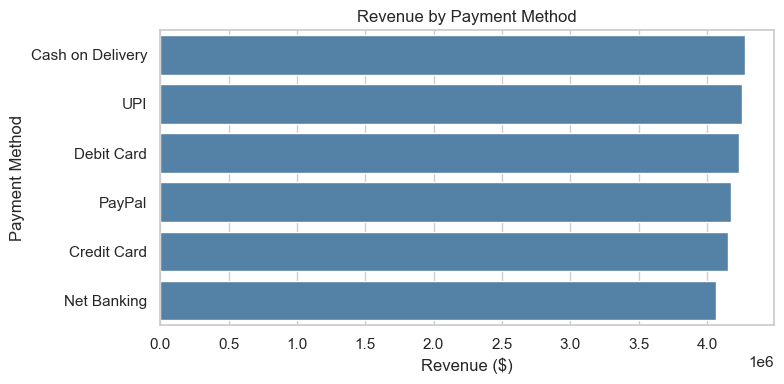

In [18]:


plt.figure(figsize=(8, 4))   


sns.barplot(data=rev_payment, x="revenue", y="payment_method", color="steelblue")

plt.title("Revenue by Payment Method")  
plt.xlabel("Revenue ($)")               
plt.ylabel("Payment Method")           
plt.tight_layout()  
plt.show()

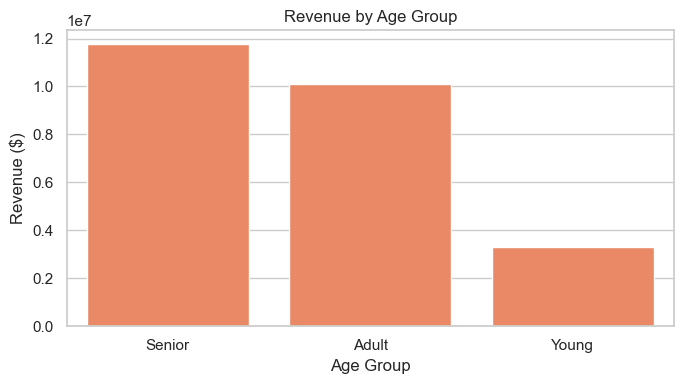

In [19]:

plt.figure(figsize=(7, 4))
sns.barplot(data=rev_age, x="age_group", y="revenue", color="coral")
plt.title("Revenue by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Revenue ($)")
plt.tight_layout()
plt.show()

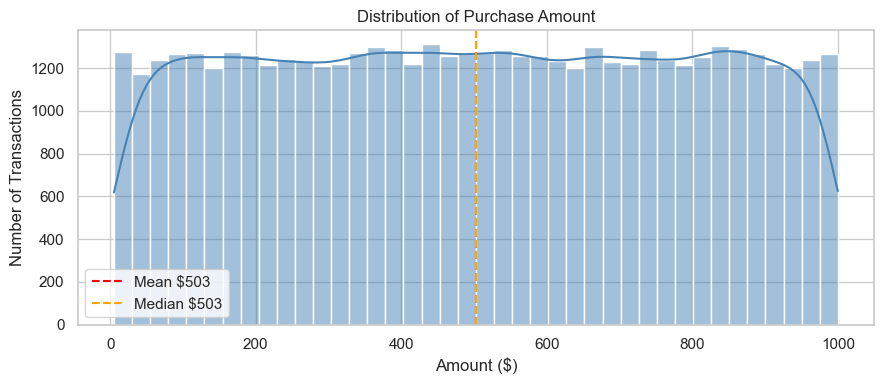

Mean:   $503.16
Median: $503.11


In [20]:


plt.figure(figsize=(9, 4))
sns.histplot(df["purchase_amount"], bins=40, kde=True, color="steelblue")


mean_val   = df["purchase_amount"].mean()
median_val = df["purchase_amount"].median()

plt.axvline(mean_val,   color="red",    linestyle="--", label=f"Mean ${mean_val:,.0f}")
plt.axvline(median_val, color="orange", linestyle="--", label=f"Median ${median_val:,.0f}")

plt.title("Distribution of Purchase Amount")
plt.xlabel("Amount ($)")
plt.ylabel("Number of Transactions")
plt.legend()  
plt.tight_layout()
plt.show()

print(f"Mean:   ${mean_val:,.2f}")
print(f"Median: ${median_val:,.2f}")

## Step 6 — Monthly Revenue Trend



In [21]:


monthly = df.groupby("year_month").agg(
    revenue   = ("purchase_amount", "sum"),
    orders    = ("transaction_id",  "nunique"),
    customers = ("customer_id",     "nunique")
).reset_index().sort_values("year_month")

print("Monthly Revenue:")
print(monthly.head(6))

Monthly Revenue:
  year_month     revenue  orders  customers
0    2023-03   802390.44    1560        100
1    2023-04  1046921.48    2049        100
2    2023-05  1050553.40    2092        100
3    2023-06  1011635.06    2029        100
4    2023-07  1105402.88    2154        100
5    2023-08  1044738.24    2120        100


In [22]:

monthly["prev_revenue"] = monthly["revenue"].shift(1)


monthly["growth_pct"] = (
    (monthly["revenue"] - monthly["prev_revenue"])
    / monthly["prev_revenue"]
    * 100
).round(2)

print("Monthly Revenue with Growth %:")
print(monthly[["year_month","revenue","prev_revenue","growth_pct"]].to_string(index=False))

Monthly Revenue with Growth %:
year_month    revenue  prev_revenue  growth_pct
   2023-03  802390.44           NaN         NaN
   2023-04 1046921.48     802390.44       30.48
   2023-05 1050553.40    1046921.48        0.35
   2023-06 1011635.06    1050553.40       -3.70
   2023-07 1105402.88    1011635.06        9.27
   2023-08 1044738.24    1105402.88       -5.49
   2023-09 1030080.62    1044738.24       -1.40
   2023-10 1046800.13    1030080.62        1.62
   2023-11 1016654.63    1046800.13       -2.88
   2023-12 1071642.15    1016654.63        5.41
   2024-01 1101023.49    1071642.15        2.74
   2024-02 1004235.75    1101023.49       -8.79
   2024-03 1018957.55    1004235.75        1.47
   2024-04 1047109.76    1018957.55        2.76
   2024-05 1070447.76    1047109.76        2.23
   2024-06 1032452.78    1070447.76       -3.55
   2024-07 1065266.58    1032452.78        3.18
   2024-08 1061115.60    1065266.58       -0.39
   2024-09 1034725.55    1061115.60       -2.49
   2024-1

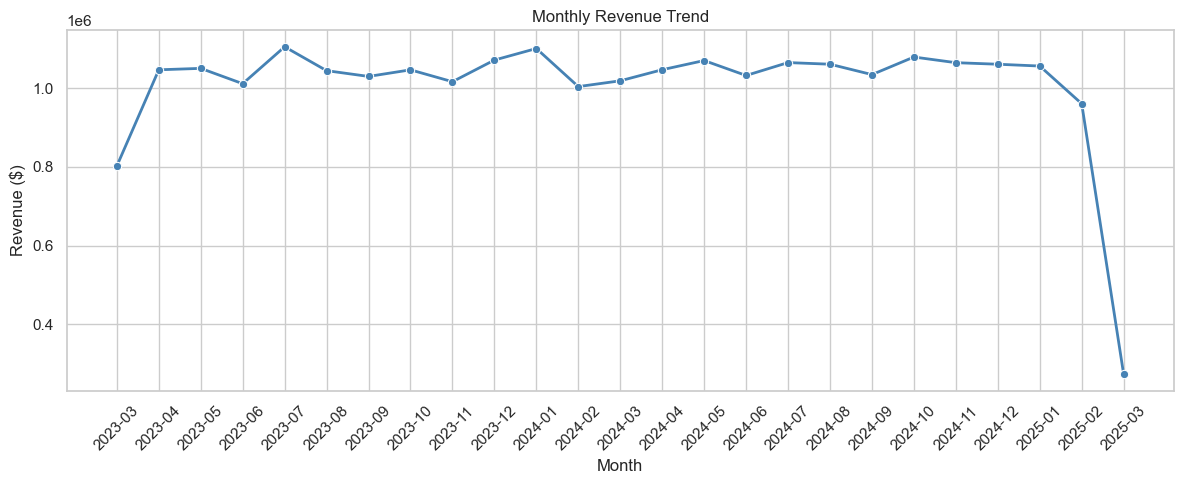

In [23]:

plt.figure(figsize=(12, 5))
sns.lineplot(data=monthly, x="year_month", y="revenue", marker="o", color="steelblue", linewidth=2)
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue ($)")
plt.xticks(rotation=45)  
plt.tight_layout()
plt.show()

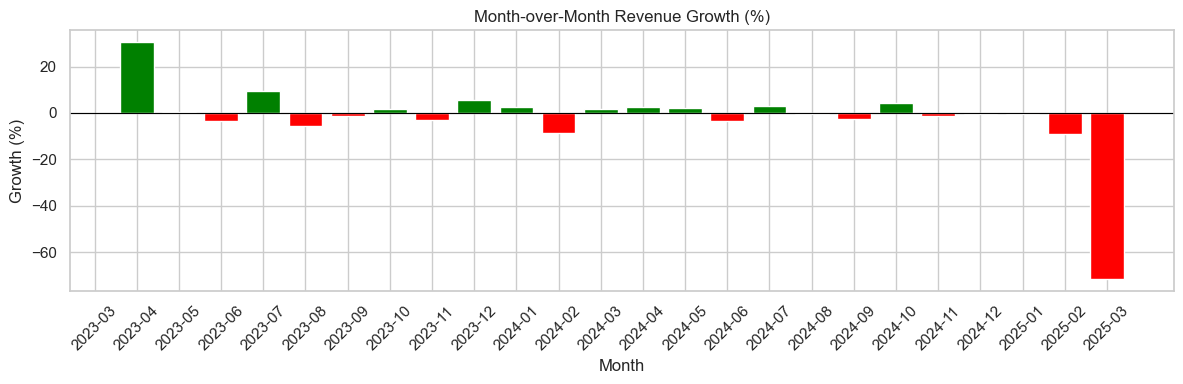

In [24]:

colors = ["green" if x > 0 else "red" for x in monthly["growth_pct"].fillna(0)]


plt.figure(figsize=(12, 4))
plt.bar(monthly["year_month"], monthly["growth_pct"], color=colors)
plt.axhline(0, color="black", linewidth=0.8)  # line at zero
plt.title("Month-over-Month Revenue Growth (%)")
plt.xlabel("Month")
plt.ylabel("Growth (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Step 7 — Customer Value (CLV per Customer)



In [25]:
customer_summary = df.groupby("customer_id").agg(
    total_orders    = ("transaction_id",  "nunique"),  
    total_spent     = ("purchase_amount", "sum"),     
    avg_order_value = ("purchase_amount", "mean"),     
    first_purchase  = ("transaction_date","min"),      
    last_purchase   = ("transaction_date","max")      
).reset_index()


customer_summary["days_active"] = (
    customer_summary["last_purchase"] - customer_summary["first_purchase"]
).dt.days

customer_summary = customer_summary.sort_values("total_spent", ascending=False)

print("Top 10 Customers:")
cols = ["customer_id","total_orders","total_spent","avg_order_value","days_active"]
print(customer_summary[cols].head(10).round(2).to_string(index=False))

Top 10 Customers:
  customer_id  total_orders  total_spent  avg_order_value  days_active
sophia harris           568    296354.98           521.75          730
  james allen           545    278079.15           510.24          730
  olivia hall           534    277302.09           519.29          729
isabella hall           539    275798.04           511.68          729
noah anderson           545    274347.15           503.39          728
   emma clark           546    274313.60           502.41          729
    ava clark           517    273776.79           529.55          729
  elijah hall           543    271861.61           500.67          729
  james lewis           543    271007.68           499.09          725
     ava hall           517    268756.73           519.84          725


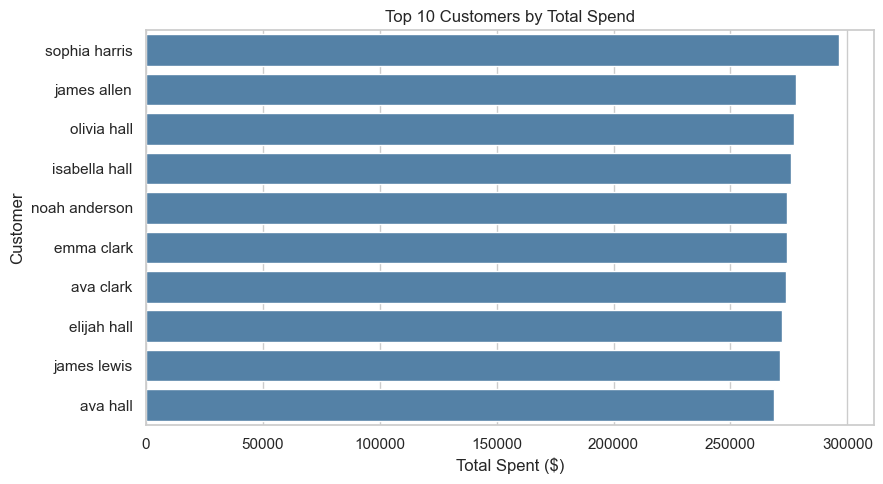

In [26]:

top10 = customer_summary.head(10)

plt.figure(figsize=(9, 5))
sns.barplot(data=top10, x="total_spent", y="customer_id", color="steelblue")
plt.title("Top 10 Customers by Total Spend")
plt.xlabel("Total Spent ($)")
plt.ylabel("Customer")
plt.tight_layout()
plt.show()

## Step 8 — RFM Segmentation

📘 **RFM = Recency · Frequency · Monetary**



In [27]:

snapshot_date = df["transaction_date"].max() + pd.Timedelta(days=1)
print("Snapshot date:", snapshot_date.date())


rfm = df.groupby("customer_id").agg(
    last_purchase_date = ("transaction_date", "max"),
    frequency          = ("transaction_id",   "nunique"),
    monetary           = ("purchase_amount",  "sum")
).reset_index()


rfm["recency"] = (snapshot_date - rfm["last_purchase_date"]).dt.days

print("\nRFM base values (first 5):")
print(rfm[["customer_id","recency","frequency","monetary"]].head())

Snapshot date: 2025-03-09

RFM base values (first 5):
    customer_id  recency  frequency   monetary
0     ava allen        1        494  247865.13
1  ava anderson        1        491  246801.09
2     ava clark        2        517  273776.79
3      ava hall        6        517  268756.73
4    ava harris        4        520  266846.08


In [33]:
rfm["r_score"] = pd.qcut(
    rfm["recency"].rank(method="first", ascending=False),
    q=5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

rfm["f_score"] = pd.qcut(
    rfm["frequency"].rank(method="first"),
    q=5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

rfm["m_score"] = pd.qcut(
    rfm["monetary"].rank(method="first"),
    q=5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

rfm["rfm_total"] = rfm["r_score"] + rfm["f_score"] + rfm["m_score"]

print("RFM scores (first 5):")
print(rfm[["customer_id","r_score","f_score","m_score","rfm_total"]].head())

RFM scores (first 5):
    customer_id  r_score  f_score  m_score  rfm_total
0     ava allen        3        2        2          7
1  ava anderson        3        2        2          7
2     ava clark        2        5        5         12
3      ava hall        1        5        5         11
4    ava harris        1        5        5         11


In [34]:


def assign_segment(row):
    if row["r_score"] >= 4 and row["f_score"] >= 4 and row["m_score"] >= 4:
        return "Champions"         
    elif row["r_score"] >= 3 and row["f_score"] >= 4:
        return "Loyal Customers"   # buys often
    elif row["r_score"] >= 4 and row["f_score"] <= 2:
        return "New Customers"     
    elif row["r_score"] <= 2 and row["f_score"] >= 3:
        return "At Risk"          
    elif row["m_score"] >= 4:
        return "High Spenders"     
    else:
        return "Regular Customers"


rfm["segment"] = rfm.apply(assign_segment, axis=1)

print("Customers per segment:")
print(rfm["segment"].value_counts())

Customers per segment:
segment
Regular Customers    30
At Risk              23
Champions            17
New Customers        14
Loyal Customers       9
High Spenders         7
Name: count, dtype: int64


In [35]:

seg_summary = rfm.groupby("segment").agg(
    customers     = ("customer_id", "nunique"),
    avg_recency   = ("recency",     "mean"),
    avg_frequency = ("frequency",   "mean"),
    total_revenue = ("monetary",    "sum"),
    avg_spend     = ("monetary",    "mean")
).reset_index().sort_values("total_revenue", ascending=False).round(2)

print(seg_summary.to_string(index=False))

          segment  customers  avg_recency  avg_frequency  total_revenue  avg_spend
Regular Customers         30         2.73         481.73     7207559.16  240251.97
          At Risk         23         3.22         511.00     5908020.08  256870.44
        Champions         17         1.00         526.06     4553467.11  267851.01
    New Customers         14         1.00         480.07     3369527.46  240680.53
  Loyal Customers          9         1.33         517.78     2315573.21  257285.91
    High Spenders          7         1.71         495.86     1803842.63  257691.80


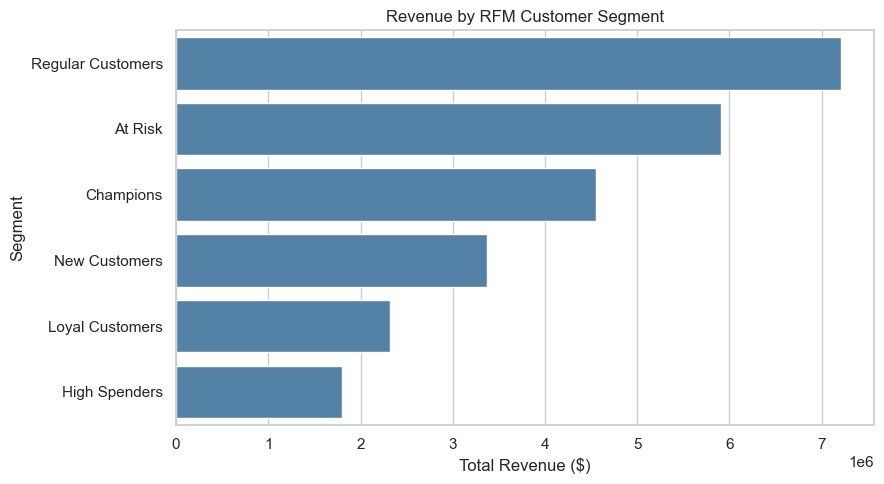

In [36]:
plt.figure(figsize=(9, 5))
sns.barplot(data=seg_summary, x="total_revenue", y="segment", color="steelblue")
plt.title("Revenue by RFM Customer Segment")
plt.xlabel("Total Revenue ($)")
plt.ylabel("Segment")
plt.tight_layout()
plt.show()

## Step 9 — Pareto Analysis (80/20 Rule)

📘 **The 80/20 Rule:** 20% of customers generate 80% of revenue.



In [37]:

pareto = customer_summary.sort_values("total_spent", ascending=False).copy()


pareto["revenue_share"] = pareto["total_spent"] / pareto["total_spent"].sum()


pareto["cumulative_rev_pct"] = pareto["revenue_share"].cumsum() * 100


pareto["rank"] = np.arange(1, len(pareto) + 1)


pareto["cumulative_cust_pct"] = pareto["rank"] / len(pareto) * 100

print("Pareto Table (top 5):")
cols = ["customer_id","total_spent","cumulative_rev_pct","cumulative_cust_pct"]
print(pareto[cols].head().round(2).to_string(index=False))

Pareto Table (top 5):
  customer_id  total_spent  cumulative_rev_pct  cumulative_cust_pct
sophia harris    296354.98                1.18                  1.0
  james allen    278079.15                2.28                  2.0
  olivia hall    277302.09                3.39                  3.0
isabella hall    275798.04                4.48                  4.0
noah anderson    274347.15                5.57                  5.0


In [38]:

top20_rev = pareto.loc[pareto["cumulative_cust_pct"] <= 20, "total_spent"].sum()
top20_share = top20_rev / pareto["total_spent"].sum() * 100

print(f"Top 20% of customers contribute: {top20_share:.1f}% of revenue")

Top 20% of customers contribute: 21.5% of revenue


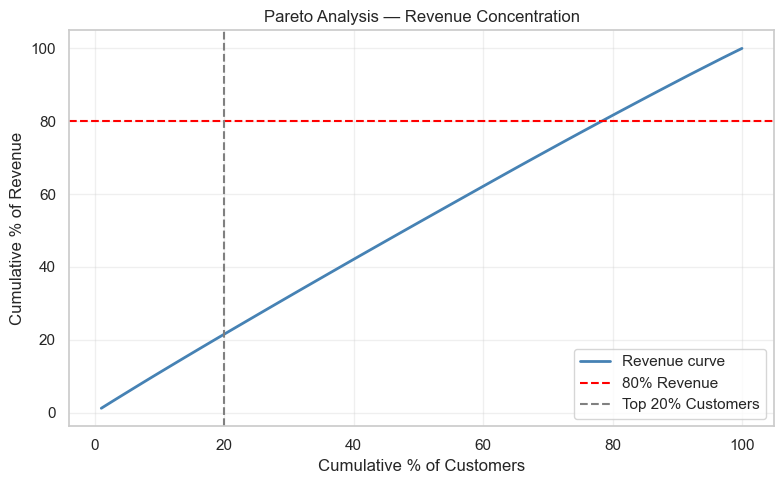

In [39]:
plt.figure(figsize=(8, 5))
plt.plot(pareto["cumulative_cust_pct"], pareto["cumulative_rev_pct"],
         color="steelblue", linewidth=2, label="Revenue curve")
plt.axhline(80, color="red",  linestyle="--", label="80% Revenue")
plt.axvline(20, color="gray", linestyle="--", label="Top 20% Customers")
plt.title("Pareto Analysis — Revenue Concentration")
plt.xlabel("Cumulative % of Customers")
plt.ylabel("Cumulative % of Revenue")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Step 10 — Cohort Retention Heatmap

📘 **Cohort = group of customers who first purchased in the same month.**



In [40]:

first_purchase = (df.groupby("customer_id")["transaction_date"]
                    .min()
                    .reset_index())
first_purchase.columns = ["customer_id", "first_date"]
first_purchase["cohort_month"] = first_purchase["first_date"].dt.to_period("M")

print("First purchase per customer:")
print(first_purchase.head())

First purchase per customer:
    customer_id first_date cohort_month
0     ava allen 2023-03-10      2023-03
1  ava anderson 2023-03-09      2023-03
2     ava clark 2023-03-09      2023-03
3      ava hall 2023-03-09      2023-03
4    ava harris 2023-03-09      2023-03


In [41]:

df2 = pd.merge(df, first_purchase[["customer_id","cohort_month"]], on="customer_id")

df2["order_month"] = df2["transaction_date"].dt.to_period("M")


df2["cohort_index"] = (
    (df2["order_month"].dt.year  - df2["cohort_month"].dt.year) * 12
    + (df2["order_month"].dt.month - df2["cohort_month"].dt.month)
)

print("Sample:")
print(df2[["customer_id","cohort_month","order_month","cohort_index"]].head(6))

Sample:
       customer_id cohort_month order_month  cohort_index
0         ava hall      2023-03     2023-04             1
1      sophia hall      2023-03     2023-07             4
2  elijah thompson      2023-03     2023-09             6
3     elijah white      2023-03     2023-06             3
4       ava harris      2023-03     2024-10            19
5    elijah harris      2023-03     2025-01            22


In [42]:

cohort_counts = (df2.groupby(["cohort_month","cohort_index"])["customer_id"]
                   .nunique()
                   .reset_index())
cohort_counts.columns = ["cohort_month","cohort_index","customers"]


cohort_pivot = cohort_counts.pivot_table(
    index="cohort_month", columns="cohort_index", values="customers"
)


retention = cohort_pivot.divide(cohort_pivot.iloc[:, 0], axis=0) * 100

print("Retention % matrix:")
print(retention.round(1))

Retention % matrix:
cohort_index     0      1      2      3      4      5      6      7      8   \
cohort_month                                                                  
2023-03       100.0  100.0  100.0  100.0  100.0  100.0  100.0  100.0  100.0   

cohort_index     9      10     11     12     13     14     15     16     17  \
cohort_month                                                                  
2023-03       100.0  100.0  100.0  100.0  100.0  100.0  100.0  100.0  100.0   

cohort_index     18     19     20     21     22     23    24  
cohort_month                                                  
2023-03       100.0  100.0  100.0  100.0  100.0  100.0  99.0  


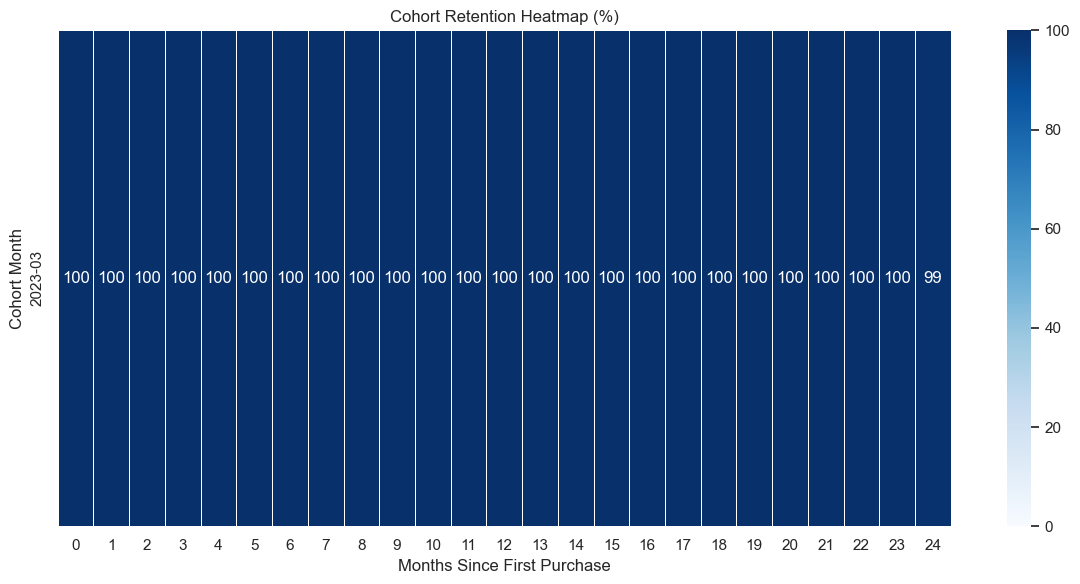

How to read this:
  Row    = month customers first bought
  Col 0  = first month (always 100%)
  Col 1  = % who returned next month
  Col 2  = % who returned 2 months later


In [43]:



plt.figure(figsize=(12, 6))
sns.heatmap(retention, annot=True, fmt=".0f", cmap="Blues",
            vmin=0, vmax=100, linewidths=0.5)
plt.title("Cohort Retention Heatmap (%)")
plt.xlabel("Months Since First Purchase")
plt.ylabel("Cohort Month")
plt.tight_layout()
plt.show()

print("How to read this:")
print("  Row    = month customers first bought")
print("  Col 0  = first month (always 100%)")
print("  Col 1  = % who returned next month")
print("  Col 2  = % who returned 2 months later")

#  END